In [27]:
from transformer_architecture import Transformer

import torch
import pandas as pd
import numpy as np
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.__version__)
print(DEVICE)

2.5.1
cuda


In [28]:
df = pd.read_csv("data/cleaned_dataset.csv")
df.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,44.99,0.16,0.0,0.31,65.957440,302.59482,1.64,760.000000,179.426579,60.0,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,45.60,0.09,0.0,0.50,84.745766,236.89185,1.74,730.000000,179.426579,60.0,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,37.83,0.13,0.0,0.56,81.159424,210.86215,1.40,1029.999971,179.426579,60.0,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,36.66,0.31,0.0,0.63,67.021280,229.96822,1.40,1220.000029,190.683814,60.0,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,44.24,0.33,0.0,0.56,62.921350,204.23125,1.20,1029.999971,211.382074,60.0,652230.0,33.93911,67.709953


In [29]:
df[df["Entity"] == "Somalia"]

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
2520,Somalia,2000,1.892501,0.4,93.28,0.23,0.0,0.00,0.000000,340.10217,11.22,490.000000,350.168162,25.0,637657.0,5.152149,46.199616
2521,Somalia,2001,4.504616,0.4,93.26,0.25,0.0,0.00,0.000000,332.43317,11.32,510.000000,350.168162,25.0,637657.0,5.152149,46.199616
2522,Somalia,2002,7.400000,0.5,92.58,0.26,0.0,0.00,0.000000,346.37854,11.39,569.999993,350.168162,25.0,637657.0,5.152149,46.199616
2523,Somalia,2003,9.708441,0.5,92.80,0.26,0.0,0.00,0.000000,334.05520,11.51,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2524,Somalia,2004,12.304850,0.6,93.00,0.26,0.0,0.00,0.000000,322.42703,11.48,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2525,Somalia,2005,14.900722,0.6,93.30,0.27,0.0,0.00,0.000000,314.66333,11.47,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2526,Somalia,2006,15.233786,0.7,93.47,0.28,0.0,0.00,0.000000,307.72528,11.60,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2527,Somalia,2007,20.100733,0.7,93.02,0.29,0.0,0.00,0.000000,302.79350,11.53,620.000005,350.168162,25.0,637657.0,5.152149,46.199616
2528,Somalia,2008,22.710230,0.8,93.37,0.30,0.0,0.00,0.000000,291.03380,11.74,620.000005,350.168162,25.0,637657.0,5.152149,46.199616
2529,Somalia,2009,25.329666,1.0,93.63,0.31,0.0,0.00,0.000000,283.20413,11.82,610.000014,350.168162,25.0,637657.0,5.152149,46.199616


# Data Processing

In [30]:
SEQ_LEN = 8
VAL_TIME = 1
TEST_TIME = 1
OOD_TEST_TIME = 2

### Train Val Test Splitting

In [31]:
entity = df["Entity"].unique()
year = df["Year"].unique()
year_start = np.arange(year.min(), year.max() - SEQ_LEN + 1, 1)
print(year_start)
len(entity), len(year), len(year_start)

[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012]


(145, 21, 13)

In [32]:
train_year = year_start[:- VAL_TIME - TEST_TIME - OOD_TEST_TIME]
val_year = year_start[- VAL_TIME - TEST_TIME - OOD_TEST_TIME: - TEST_TIME - OOD_TEST_TIME]
test_year = year_start[- TEST_TIME - OOD_TEST_TIME: - OOD_TEST_TIME]
ood_test_year = year_start[- OOD_TEST_TIME:]
train_year, val_year, test_year, ood_test_year

(array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008]),
 array([2009]),
 array([2010]),
 array([2011, 2012]))

### Normalization

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [34]:
scaler_years = set(year[:- VAL_TIME - TEST_TIME - OOD_TEST_TIME])
scaler_years

{np.int64(2000),
 np.int64(2001),
 np.int64(2002),
 np.int64(2003),
 np.int64(2004),
 np.int64(2005),
 np.int64(2006),
 np.int64(2007),
 np.int64(2008),
 np.int64(2009),
 np.int64(2010),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016)}

In [35]:
scaler_df = df[df["Year"].isin(scaler_years)].drop(columns=["Entity", "Year"])

In [36]:
scaler.fit(scaler_df)

,copy,True
,with_mean,True
,with_std,True


In [37]:
df[df.columns[2:]] = scaler.transform(df[df.columns[2:]])

df_global = df.drop(columns=["Entity"]).groupby('Year', as_index=False).mean()
df_global.head()

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,2000,-0.173365,-0.102433,0.055485,-0.053051,-0.000135,-0.077248,0.011062,-0.038259,0.242942,-0.041096,-0.275143,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
1,2001,-0.155280,-0.088909,0.039796,-0.050245,0.005179,-0.082559,-0.013827,-0.035893,0.212047,-0.038231,-0.280080,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
2,2002,-0.128914,-0.075306,0.036260,-0.043046,0.005462,-0.076877,-0.003851,-0.024942,0.173836,-0.036085,-0.258630,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
3,2003,-0.108627,-0.061324,0.023585,-0.034198,0.001520,-0.074998,-0.019013,-0.011661,0.178610,-0.027841,-0.190461,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
4,2004,-0.088583,-0.048111,0.018931,-0.026900,0.011044,-0.060752,-0.014136,0.006960,0.150179,-0.019054,-0.121281,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18


### Entity - Year pair

In [38]:
def generate_pair(years):
    pairs = []

    for year in years:
        for e in entity:
            pairs.append((e, year))

    return pairs

In [39]:
ds_train = generate_pair(train_year)
ds_val = generate_pair(val_year)
ds_test = generate_pair(test_year)
ds_ood_test = generate_pair(ood_test_year)

len(ds_train), len(ds_val), len(ds_test), len(ds_ood_test)

(1305, 145, 145, 290)

### Data Loader

In [40]:
from torch.utils.data import DataLoader
from transformers import get_cosine_schedule_with_warmup

In [41]:
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 2.5e-3

HIDDEN_DIM = 128

In [42]:
train_loader = DataLoader(ds_train, batch_size = BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ds_val, batch_size = BATCH_SIZE)
test_loader = DataLoader(ds_test, batch_size = BATCH_SIZE)
ood_test_loader = DataLoader(ds_ood_test, batch_size = BATCH_SIZE)

In [43]:
col_count = len(df_global.columns)

model = Transformer(
    hidden_dim=HIDDEN_DIM,
    seq_len=SEQ_LEN,
    corpus_size=col_count,
    encoder_attention_heads=4,
    encoder_blocks=4,
    decoder_attention_heads=4,
    decoder_blocks=4,
    use_embedding=False,
    embedding_replacement=torch.nn.Linear(col_count, HIDDEN_DIM)
).to(DEVICE)

criterion = torch.nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-5)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(EPOCHS*len(train_loader)*0.05),
    num_training_steps=EPOCHS*len(train_loader)
)

In [44]:
df = df.sort_values(["Entity", "Year"]).set_index(["Entity", "Year"], drop=False)
df = df.drop(columns=["Entity"])
df_global = df_global.sort_values("Year").set_index("Year", drop=False)

entity_groups = {
    k: v.values for k, v in df.groupby(level=0)
}
global_array = df_global.values
years_index = {k: v for v, k in enumerate(df_global.index.to_numpy())}
years_index

{np.int64(2000): 0,
 np.int64(2001): 1,
 np.int64(2002): 2,
 np.int64(2003): 3,
 np.int64(2004): 4,
 np.int64(2005): 5,
 np.int64(2006): 6,
 np.int64(2007): 7,
 np.int64(2008): 8,
 np.int64(2009): 9,
 np.int64(2010): 10,
 np.int64(2011): 11,
 np.int64(2012): 12,
 np.int64(2013): 13,
 np.int64(2014): 14,
 np.int64(2015): 15,
 np.int64(2016): 16,
 np.int64(2017): 17,
 np.int64(2018): 18,
 np.int64(2019): 19,
 np.int64(2020): 20}

# Training Loop

In [ ]:
entity_groups_tensor = torch.tensor(entity_groups)
global_array_tensor = torch.tensor(global_array)

In [ ]:
def load_tensor(entities, years):
    regional_data = []
    global_data = []

    for entity, year in zip(entities, years):
        year = int(year)
        entity = entity.item() if hasattr(entity, "item") else entity

        regional_data.append(entity_groups_tensor[entity][years_index[year] : years_index[year + SEQ_LEN] + 1])
        global_data.append(global_array_tensor[years_index[year] : years_index[year + SEQ_LEN]])


    regional_data = torch.stack(regional_data).to(DEVICE, torch.float32)
    global_data = torch.stack(global_data).to(DEVICE, torch.float32)
    return regional_data, global_data

In [46]:
train_metrics = {
    "train_loss": [],
    "train_rmse": [],
    "val_loss": [],
    "val_rmse": [],
    "lr":[]
}

In [ ]:
for e in range(EPOCHS):
    model.train()
    train_loss = 0
    train_se = 0
    train_count = 0
    for entities, years in tqdm(train_loader, desc=f"Epoch {e+1:>3d} Training"):
        optimizer.zero_grad()
        regional_data, global_data = load_tensor(entities, years)
        pred = model(global_data, regional_data[:, :-1])
        ground_truth = regional_data[:, 1:]
    

        loss = criterion(pred, ground_truth)
        train_loss += loss.item()

        train_se += ((pred - ground_truth)**2).sum().item()
        train_count += pred.numel()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    print(f"        Train Loss: {train_loss/len(train_loader)}, RMSE = {(train_se/(train_count*col_count))**0.5}")
    train_metrics["train_loss"].append(train_loss/len(train_loader))
    train_metrics["train_rmse"].append((train_se/(train_count*col_count))**0.5)


    model.eval()
    val_loss = 0
    val_se = 0
    val_count = 0
    with torch.no_grad():
        for entities, years in tqdm(val_loader, desc=f"               Val"):
            regional_data, global_data = load_tensor(entities, years)
            pred = model(global_data, regional_data[:, :-1])
            ground_truth = regional_data[:, -1]
            pred = pred[:, -1]
        

            loss = criterion(pred, ground_truth)
            val_loss += loss.item()

            val_se += ((pred - ground_truth)**2).sum().item()
            val_count += pred.numel()

    print(f"          Val Loss: {val_loss/len(val_loader)}, RMSE = {(val_se/(val_count*col_count))**0.5}")
    train_metrics["val_loss"].append(val_loss/len(val_loader))
    train_metrics["val_rmse"].append((val_se/(val_count*col_count))**0.5)

    print("                lr:", scheduler.get_last_lr()[0])
    train_metrics["lr"].append(scheduler.get_last_lr()[0])

    print()

Epoch   1 Training:   0%|          | 0/41 [00:00<?, ?it/s]/root/miniconda3/envs/torch/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
Epoch   1 Training: 100%|██████████| 41/41 [00:04<00:00,  8.47it/s]


        Train Loss: 125.42920684814453, RMSE = 1415.8806116736714


               Val:  60%|██████    | 3/5 [00:00<00:00, 10.36it/s]

tensor(0.5169, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(2.3039, device='cuda:0', grad_fn=<StdBackward0>)
tensor(0.5169, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(2.3039, device='cuda:0', grad_fn=<StdBackward0>)
tensor(0.5169, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(2.3039, device='cuda:0', grad_fn=<StdBackward0>)
tensor(0.5169, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(2.3039, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 11.00it/s]


tensor(0.5169, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(2.3059, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 125.74739837646484, RMSE = 501.89984919373074
                lr: 0.0010049019607843138



Epoch   2 Training: 100%|██████████| 41/41 [00:03<00:00, 10.48it/s]


        Train Loss: 124.93840026855469, RMSE = 1410.4672338003888


               Val:  60%|██████    | 3/5 [00:00<00:00, 27.35it/s]

tensor(1.1806, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(4.9831, device='cuda:0', grad_fn=<StdBackward0>)
tensor(1.1806, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(4.9831, device='cuda:0', grad_fn=<StdBackward0>)
tensor(1.1806, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(4.9831, device='cuda:0', grad_fn=<StdBackward0>)
tensor(1.1806, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(4.9831, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 24.09it/s]


tensor(1.1806, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(4.9874, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 125.06082916259766, RMSE = 499.1389447908233
                lr: 0.0020098039215686275



Epoch   3 Training: 100%|██████████| 41/41 [00:04<00:00,  9.07it/s]


        Train Loss: 123.81319427490234, RMSE = 1397.7227971327222


               Val:  40%|████      | 2/5 [00:00<00:00, 17.97it/s]

tensor(2.8854, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(11.2683, device='cuda:0', grad_fn=<StdBackward0>)
tensor(2.8854, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(11.2683, device='cuda:0', grad_fn=<StdBackward0>)
tensor(2.8854, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(11.2683, device='cuda:0', grad_fn=<StdBackward0>)
tensor(2.8854, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(11.2683, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 20.14it/s]


tensor(2.8854, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(11.2780, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 123.4356689453125, RMSE = 492.63105030452346
                lr: 0.0024992831984501267



Epoch   4 Training: 100%|██████████| 41/41 [00:04<00:00,  9.80it/s]


        Train Loss: 121.84381866455078, RMSE = 1375.470096442266


               Val:  40%|████      | 2/5 [00:00<00:00, 13.90it/s]

tensor(5.0735, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(20.0970, device='cuda:0', grad_fn=<StdBackward0>)
tensor(5.0735, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(20.0970, device='cuda:0', grad_fn=<StdBackward0>)
tensor(5.0735, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(20.0970, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 18.72it/s]


tensor(5.0735, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(20.0970, device='cuda:0', grad_fn=<StdBackward0>)
tensor(5.0735, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(20.1144, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 121.16686248779297, RMSE = 483.5435472312349
                lr: 0.002493756568180919



Epoch   5 Training: 100%|██████████| 41/41 [00:03<00:00, 10.63it/s]


        Train Loss: 119.30561065673828, RMSE = 1346.7277532520484


               Val:  40%|████      | 2/5 [00:00<00:00, 16.01it/s]

tensor(7.8903, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(30.7579, device='cuda:0', grad_fn=<StdBackward0>)
tensor(7.8903, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(30.7579, device='cuda:0', grad_fn=<StdBackward0>)
tensor(7.8903, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(30.7579, device='cuda:0', grad_fn=<StdBackward0>)


               Val:  80%|████████  | 4/5 [00:00<00:00, 17.77it/s]

tensor(7.8903, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(30.7579, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 16.57it/s]


tensor(7.8903, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(30.7845, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 118.41971588134766, RMSE = 472.52737559812886
                lr: 0.0024827940974270135



Epoch   6 Training: 100%|██████████| 41/41 [00:04<00:00,  9.75it/s]


        Train Loss: 116.39451599121094, RMSE = 1313.8503352544672


               Val:  40%|████      | 2/5 [00:00<00:00, 18.23it/s]

tensor(11.0572, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(42.8963, device='cuda:0', grad_fn=<StdBackward0>)
tensor(11.0572, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(42.8963, device='cuda:0', grad_fn=<StdBackward0>)
tensor(11.0572, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(42.8963, device='cuda:0', grad_fn=<StdBackward0>)


               Val:  80%|████████  | 4/5 [00:00<00:00, 19.18it/s]

tensor(11.0572, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(42.8963, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 18.71it/s]


tensor(11.0572, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(42.9334, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 115.27371978759766, RMSE = 459.9940291966318
                lr: 0.0024664436976880237



Epoch   7 Training: 100%|██████████| 41/41 [00:04<00:00,  9.47it/s]


        Train Loss: 113.03236389160156, RMSE = 1275.866292133427


               Val:  40%|████      | 2/5 [00:00<00:00, 19.31it/s]

tensor(14.6362, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(56.8351, device='cuda:0', grad_fn=<StdBackward0>)
tensor(14.6362, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(56.8351, device='cuda:0', grad_fn=<StdBackward0>)
tensor(14.6362, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(56.8351, device='cuda:0', grad_fn=<StdBackward0>)


               Val:  80%|████████  | 4/5 [00:00<00:00, 19.45it/s]

tensor(14.6362, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(56.8351, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 19.24it/s]


tensor(14.6363, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(56.8843, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 111.67827606201172, RMSE = 445.61582533961183
                lr: 0.0024447768284176054



Epoch   8 Training: 100%|██████████| 41/41 [00:04<00:00, 10.24it/s]


        Train Loss: 109.2751693725586, RMSE = 1233.291753259951


               Val: 100%|██████████| 5/5 [00:00<00:00, 25.59it/s]

tensor(18.3078, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(71.7008, device='cuda:0', grad_fn=<StdBackward0>)
tensor(18.3078, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(71.7008, device='cuda:0', grad_fn=<StdBackward0>)
tensor(18.3078, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(71.7008, device='cuda:0', grad_fn=<StdBackward0>)
tensor(18.3078, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(71.7008, device='cuda:0', grad_fn=<StdBackward0>)
tensor(18.3078, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(71.7628, device='cuda:0', grad_fn=<StdBackward0>)


          Val Loss: 107.88407135009766, RMSE = 430.318520761476
                lr: 0.0024178881847097744



Epoch   9 Training: 100%|██████████| 41/41 [00:04<00:00,  9.86it/s]


        Train Loss: 105.3782958984375, RMSE = 1189.2550538642931


               Val:  40%|████      | 2/5 [00:00<00:00, 19.65it/s]

tensor(22.5512, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(87.4618, device='cuda:0', grad_fn=<StdBackward0>)
tensor(22.5512, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(87.4618, device='cuda:0', grad_fn=<StdBackward0>)
tensor(22.5512, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(87.4618, device='cuda:0', grad_fn=<StdBackward0>)
tensor(22.5512, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(87.4618, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 19.54it/s]


tensor(22.5512, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(87.5374, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 103.7847671508789, RMSE = 414.0119001288198
                lr: 0.002385895283433816



Epoch  10 Training: 100%|██████████| 41/41 [00:04<00:00,  8.85it/s]


        Train Loss: 101.1535415649414, RMSE = 1141.459659057956


               Val:  60%|██████    | 3/5 [00:00<00:00, 24.89it/s]

tensor(26.7631, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(104.3619, device='cuda:0', grad_fn=<StdBackward0>)
tensor(26.7631, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(104.3619, device='cuda:0', grad_fn=<StdBackward0>)
tensor(26.7631, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(104.3619, device='cuda:0', grad_fn=<StdBackward0>)
tensor(26.7631, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(104.3619, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 19.00it/s]


tensor(26.7631, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(104.4521, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 99.432373046875, RMSE = 396.61158146444
                lr: 0.0023489379496265802



Epoch  11 Training: 100%|██████████| 41/41 [00:03<00:00, 10.52it/s]


        Train Loss: 96.69792175292969, RMSE = 1091.0527321664229


               Val:  60%|██████    | 3/5 [00:00<00:00, 23.19it/s]

tensor(31.4071, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(122.1210, device='cuda:0', grad_fn=<StdBackward0>)
tensor(31.4071, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(122.1210, device='cuda:0', grad_fn=<StdBackward0>)
tensor(31.4071, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(122.1210, device='cuda:0', grad_fn=<StdBackward0>)
tensor(31.4071, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(122.1210, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.31it/s]


tensor(31.4071, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(122.2266, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 94.8561782836914, RMSE = 378.27235216678616
                lr: 0.002307177705386889



Epoch  12 Training: 100%|██████████| 41/41 [00:04<00:00,  9.14it/s]


        Train Loss: 91.95024871826172, RMSE = 1037.4009706696636


               Val: 100%|██████████| 5/5 [00:00<00:00, 29.92it/s]


tensor(36.3045, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(141.0160, device='cuda:0', grad_fn=<StdBackward0>)
tensor(36.3045, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(141.0160, device='cuda:0', grad_fn=<StdBackward0>)
tensor(36.3045, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(141.0160, device='cuda:0', grad_fn=<StdBackward0>)
tensor(36.3045, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(141.0160, device='cuda:0', grad_fn=<StdBackward0>)
tensor(36.3045, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(141.1379, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 89.97992706298828, RMSE = 358.77088068513336
                lr: 0.0022607970639428906



Epoch  13 Training: 100%|██████████| 41/41 [00:04<00:00,  9.45it/s]


        Train Loss: 87.01113891601562, RMSE = 981.4640420822268


               Val:  60%|██████    | 3/5 [00:00<00:00, 23.52it/s]

tensor(41.2234, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(160.3344, device='cuda:0', grad_fn=<StdBackward0>)
tensor(41.2234, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(160.3344, device='cuda:0', grad_fn=<StdBackward0>)
tensor(41.2234, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(160.3344, device='cuda:0', grad_fn=<StdBackward0>)
tensor(41.2234, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(160.3344, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 18.89it/s]


tensor(41.2234, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(160.4730, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 85.02011108398438, RMSE = 338.8546746279906
                lr: 0.0022099987319776425



Epoch  14 Training: 100%|██████████| 41/41 [00:05<00:00,  7.78it/s]


        Train Loss: 82.00355529785156, RMSE = 924.8667419804087


               Val:  60%|██████    | 3/5 [00:00<00:00, 24.74it/s]

tensor(46.2695, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(180.1305, device='cuda:0', grad_fn=<StdBackward0>)
tensor(46.2695, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(180.1305, device='cuda:0', grad_fn=<StdBackward0>)
tensor(46.2695, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(180.1305, device='cuda:0', grad_fn=<StdBackward0>)
tensor(46.2695, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(180.1305, device='cuda:0', grad_fn=<StdBackward0>)
tensor(46.2695, device='cuda:0', grad_fn=<MeanBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 21.72it/s]


tensor(180.2862, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 79.91963195800781, RMSE = 318.4445223160597
                lr: 0.0021550047236991634



Epoch  15 Training: 100%|██████████| 41/41 [00:04<00:00, 10.07it/s]


        Train Loss: 76.82435607910156, RMSE = 866.3118398310262


               Val: 100%|██████████| 5/5 [00:00<00:00, 27.03it/s]


tensor(51.7565, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(200.4783, device='cuda:0', grad_fn=<StdBackward0>)
tensor(51.7565, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(200.4783, device='cuda:0', grad_fn=<StdBackward0>)
tensor(51.7565, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(200.4783, device='cuda:0', grad_fn=<StdBackward0>)
tensor(51.7565, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(200.4783, device='cuda:0', grad_fn=<StdBackward0>)
tensor(51.7565, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(200.6517, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 74.63738250732422, RMSE = 297.3901535832615
                lr: 0.0020960553905269054



Epoch  16 Training: 100%|██████████| 41/41 [00:04<00:00,  9.81it/s]


        Train Loss: 71.50147247314453, RMSE = 806.0803473828038


               Val:  60%|██████    | 3/5 [00:00<00:00, 18.80it/s]

tensor(56.9064, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(221.0852, device='cuda:0', grad_fn=<StdBackward0>)
tensor(56.9064, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(221.0852, device='cuda:0', grad_fn=<StdBackward0>)
tensor(56.9064, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(221.0852, device='cuda:0', grad_fn=<StdBackward0>)
tensor(56.9064, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(221.0852, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 16.95it/s]


tensor(56.9064, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(221.2763, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 69.322509765625, RMSE = 276.1699002301001
                lr: 0.002033408370635413



Epoch  17 Training: 100%|██████████| 41/41 [00:04<00:00,  9.86it/s]


        Train Loss: 66.20233917236328, RMSE = 746.1327036755947


               Val:  40%|████      | 2/5 [00:00<00:00, 18.61it/s]

tensor(62.2448, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(241.6231, device='cuda:0', grad_fn=<StdBackward0>)
tensor(62.2448, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(241.6232, device='cuda:0', grad_fn=<StdBackward0>)
tensor(62.2448, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(241.6231, device='cuda:0', grad_fn=<StdBackward0>)
tensor(62.2448, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(241.6232, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 20.34it/s]


tensor(62.2448, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(241.8320, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 64.023681640625, RMSE = 254.96917494554864
                lr: 0.0019673374629461822



Epoch  18 Training: 100%|██████████| 41/41 [00:04<00:00,  8.37it/s]


        Train Loss: 60.90485382080078, RMSE = 686.2021942117325


               Val:  60%|██████    | 3/5 [00:00<00:00, 22.27it/s]

tensor(67.5890, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(262.1488, device='cuda:0', grad_fn=<StdBackward0>)
tensor(67.5890, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(262.1488, device='cuda:0', grad_fn=<StdBackward0>)
tensor(67.5890, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(262.1488, device='cuda:0', grad_fn=<StdBackward0>)
tensor(67.5890, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(262.1488, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 21.48it/s]


tensor(67.5890, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(262.3755, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 58.745460510253906, RMSE = 233.7787553767819
                lr: 0.0018981314304889463



Epoch  19 Training: 100%|██████████| 41/41 [00:03<00:00, 10.50it/s]


        Train Loss: 55.55945587158203, RMSE = 625.8173077520247


               Val:  60%|██████    | 3/5 [00:00<00:00, 26.72it/s]

tensor(73.0705, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(283.1121, device='cuda:0', grad_fn=<StdBackward0>)
tensor(73.0705, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(283.1121, device='cuda:0', grad_fn=<StdBackward0>)
tensor(73.0705, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(283.1121, device='cuda:0', grad_fn=<StdBackward0>)
tensor(73.0705, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(283.1121, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 21.22it/s]


tensor(73.0705, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(283.3569, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 53.31193161010742, RMSE = 212.13084872964285
                lr: 0.001826092738362295



Epoch  20 Training: 100%|██████████| 41/41 [00:04<00:00,  9.31it/s]


        Train Loss: 50.15766525268555, RMSE = 564.7265177470802


               Val:  40%|████      | 2/5 [00:00<00:00, 15.43it/s]

tensor(78.5343, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(304.1692, device='cuda:0', grad_fn=<StdBackward0>)
tensor(78.5343, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(304.1692, device='cuda:0', grad_fn=<StdBackward0>)
tensor(78.5343, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(304.1692, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 13.49it/s]


tensor(78.5343, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(304.1692, device='cuda:0', grad_fn=<StdBackward0>)
tensor(78.5343, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(304.4321, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 47.88511657714844, RMSE = 190.39679981373203
                lr: 0.001751536231809376



Epoch  21 Training: 100%|██████████| 41/41 [00:04<00:00,  8.95it/s]


        Train Loss: 44.66547775268555, RMSE = 502.66694563850916


               Val:  60%|██████    | 3/5 [00:00<00:00, 22.00it/s]

tensor(83.9532, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(325.5352, device='cuda:0', grad_fn=<StdBackward0>)
tensor(83.9532, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(325.5352, device='cuda:0', grad_fn=<StdBackward0>)
tensor(83.9532, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(325.5352, device='cuda:0', grad_fn=<StdBackward0>)
tensor(83.9532, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(325.5351, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 22.17it/s]


tensor(83.9532, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(325.8166, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 42.37238311767578, RMSE = 168.3751571179156
                lr: 0.0016747877601861548



Epoch  22 Training: 100%|██████████| 41/41 [00:05<00:00,  7.69it/s]


        Train Loss: 39.18052673339844, RMSE = 440.63475591764814


               Val:  40%|████      | 2/5 [00:00<00:00, 14.90it/s]

tensor(89.2268, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(346.5682, device='cuda:0', grad_fn=<StdBackward0>)
tensor(89.2268, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(346.5682, device='cuda:0', grad_fn=<StdBackward0>)
tensor(89.2268, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(346.5682, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 13.71it/s]


tensor(89.2268, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(346.5682, device='cuda:0', grad_fn=<StdBackward0>)
tensor(89.2268, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(346.8678, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 36.96697235107422, RMSE = 146.71194434015578
                lr: 0.0015961827528361706



Epoch  23 Training: 100%|██████████| 41/41 [00:05<00:00,  7.46it/s]


        Train Loss: 33.858394622802734, RMSE = 380.4234777373672


               Val:  60%|██████    | 3/5 [00:00<00:00, 20.05it/s]

tensor(94.4408, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(366.7311, device='cuda:0', grad_fn=<StdBackward0>)
tensor(94.4408, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(366.7311, device='cuda:0', grad_fn=<StdBackward0>)
tensor(94.4408, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(366.7311, device='cuda:0', grad_fn=<StdBackward0>)
tensor(94.4408, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(366.7311, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 17.14it/s]


tensor(94.4408, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(367.0482, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 31.76862907409668, RMSE = 125.90563310779967
                lr: 0.0015160647530959442



Epoch  24 Training: 100%|██████████| 41/41 [00:05<00:00,  7.72it/s]


        Train Loss: 28.787595748901367, RMSE = 323.1057988951815


               Val:  40%|████      | 2/5 [00:00<00:00, 14.03it/s]

tensor(99.4333, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(386.1970, device='cuda:0', grad_fn=<StdBackward0>)
tensor(99.4333, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(386.1970, device='cuda:0', grad_fn=<StdBackward0>)


               Val:  80%|████████  | 4/5 [00:00<00:00, 15.02it/s]

tensor(99.4333, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(386.1970, device='cuda:0', grad_fn=<StdBackward0>)
tensor(99.4333, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(386.1970, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 15.57it/s]


tensor(99.4333, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(386.5308, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 26.736326217651367, RMSE = 105.82882598556387
                lr: 0.0014347839168381627



Epoch  25 Training: 100%|██████████| 41/41 [00:04<00:00,  8.22it/s]


        Train Loss: 23.768104553222656, RMSE = 266.40177378656534


               Val:  60%|██████    | 3/5 [00:00<00:00, 25.87it/s]

tensor(104.4711, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(405.3048, device='cuda:0', grad_fn=<StdBackward0>)
tensor(104.4711, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(405.3048, device='cuda:0', grad_fn=<StdBackward0>)
tensor(104.4711, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(405.3048, device='cuda:0', grad_fn=<StdBackward0>)
tensor(104.4711, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(405.3048, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 18.80it/s]


tensor(104.4710, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(405.6551, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 21.798219680786133, RMSE = 86.08766519739011
                lr: 0.0013526954821147595



Epoch  26 Training: 100%|██████████| 41/41 [00:04<00:00,  9.14it/s]


        Train Loss: 18.96012306213379, RMSE = 212.0549072023149


               Val:  60%|██████    | 3/5 [00:00<00:00, 19.62it/s]

tensor(109.2334, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(423.5415, device='cuda:0', grad_fn=<StdBackward0>)
tensor(109.2334, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(423.5415, device='cuda:0', grad_fn=<StdBackward0>)
tensor(109.2334, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(423.5415, device='cuda:0', grad_fn=<StdBackward0>)
tensor(109.2334, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(423.5415, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 18.76it/s]


tensor(109.2334, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(423.9077, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 17.08682632446289, RMSE = 67.25835337813386
                lr: 0.0012701582165883223



Epoch  27 Training: 100%|██████████| 41/41 [00:03<00:00, 10.32it/s]


        Train Loss: 14.382205963134766, RMSE = 160.3150385648156


               Val:  60%|██████    | 3/5 [00:00<00:00, 28.43it/s]

tensor(113.6412, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(440.6596, device='cuda:0', grad_fn=<StdBackward0>)
tensor(113.6412, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(440.6596, device='cuda:0', grad_fn=<StdBackward0>)
tensor(113.6412, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(440.6596, device='cuda:0', grad_fn=<StdBackward0>)
tensor(113.6412, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(440.6596, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 21.54it/s]


tensor(113.6412, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(441.0405, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 12.674609184265137, RMSE = 49.60118370128848
                lr: 0.0011875328495373322



Epoch  28 Training: 100%|██████████| 41/41 [00:03<00:00, 10.61it/s]


        Train Loss: 10.079710006713867, RMSE = 111.88077335859816


               Val:  60%|██████    | 3/5 [00:00<00:00, 19.56it/s]

tensor(117.8340, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(457.0229, device='cuda:0', grad_fn=<StdBackward0>)
tensor(117.8340, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(457.0229, device='cuda:0', grad_fn=<StdBackward0>)
tensor(117.8340, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(457.0229, device='cuda:0', grad_fn=<StdBackward0>)
tensor(117.8340, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(457.0229, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 20.15it/s]


tensor(117.8340, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(457.4180, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 8.465902328491211, RMSE = 32.7313831084781
                lr: 0.0011051804952881513



Epoch  29 Training: 100%|██████████| 41/41 [00:04<00:00,  9.46it/s]


        Train Loss: 5.928709030151367, RMSE = 65.48767999282698


               Val:  60%|██████    | 3/5 [00:00<00:00, 24.23it/s]

tensor(121.9058, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(472.7048, device='cuda:0', grad_fn=<StdBackward0>)
tensor(121.9058, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(472.7048, device='cuda:0', grad_fn=<StdBackward0>)
tensor(121.9058, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(472.7049, device='cuda:0', grad_fn=<StdBackward0>)
tensor(121.9058, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(472.7049, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.34it/s]


tensor(121.9058, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(473.1135, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 4.4043378829956055, RMSE = 16.55982025328538
                lr: 0.0010234610749641664



Epoch  30 Training: 100%|██████████| 41/41 [00:04<00:00,  9.11it/s]


        Train Loss: 2.040271520614624, RMSE = 23.554409331898125


               Val:  40%|████      | 2/5 [00:00<00:00, 19.22it/s]

tensor(125.4809, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.0597, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4809, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.0597, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4809, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.0597, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 16.09it/s]


tensor(125.4809, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.0597, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4810, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.4807, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 0.7175930142402649, RMSE = 2.0525046637789455
                lr: 0.0009427317434498198



Epoch  31 Training: 100%|██████████| 41/41 [00:04<00:00,  8.77it/s]


        Train Loss: 0.4809696674346924, RMSE = 3.9288359134847317


               Val:  60%|██████    | 3/5 [00:00<00:00, 22.81it/s]

tensor(125.4769, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6656, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4769, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6656, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4769, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6656, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4769, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6656, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 24.30it/s]


tensor(125.4769, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.0864, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 0.8128522038459778, RMSE = 2.3807580176386356
                lr: 0.0008633453284444976



Epoch  32 Training: 100%|██████████| 41/41 [00:04<00:00,  9.24it/s]


        Train Loss: 0.4668941795825958, RMSE = 3.7622239224234644


               Val:  40%|████      | 2/5 [00:00<00:00, 14.62it/s]

tensor(125.5499, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6276, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.5499, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6276, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.5499, device='cuda:0', grad_fn=<MeanBackward0>)


               Val:  80%|████████  | 4/5 [00:00<00:00, 16.23it/s]

tensor(486.6276, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.5499, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6276, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 15.14it/s]


tensor(125.5499, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.0482, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 0.8311595916748047, RMSE = 2.4052560450622984
                lr: 0.0007856487884283892



Epoch  33 Training: 100%|██████████| 41/41 [00:05<00:00,  7.75it/s]


        Train Loss: 0.46180295944213867, RMSE = 3.7552242068968793


               Val:  40%|████      | 2/5 [00:00<00:00, 16.65it/s]

tensor(125.3351, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6681, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.3351, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6681, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.3351, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6681, device='cuda:0', grad_fn=<StdBackward0>)


               Val:  80%|████████  | 4/5 [00:00<00:00, 15.29it/s]

tensor(125.3351, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6681, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 15.79it/s]


tensor(125.3351, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.0888, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 0.8443598747253418, RMSE = 2.4247543541432033
                lr: 0.0007099816962797773



Epoch  34 Training: 100%|██████████| 41/41 [00:05<00:00,  7.71it/s]


        Train Loss: 0.46307507157325745, RMSE = 3.7428442769019594


               Val:  60%|██████    | 3/5 [00:00<00:00, 26.70it/s]

tensor(125.4267, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6774, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4267, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6774, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4267, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6774, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4267, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6774, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 24.39it/s]


tensor(125.4267, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.0981, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 0.8104199767112732, RMSE = 2.384166153357973
                lr: 0.0006366747551711177



Epoch  35 Training: 100%|██████████| 41/41 [00:04<00:00,  8.54it/s]


        Train Loss: 0.4625142216682434, RMSE = 3.740325082071498


               Val:  40%|████      | 2/5 [00:00<00:00, 13.97it/s]

tensor(125.4593, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.7560, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4593, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.7560, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4593, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.7560, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 14.15it/s]


tensor(125.4593, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.7560, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4593, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.1767, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 0.7942501902580261, RMSE = 2.31353307794256
                lr: 0.0005660483532301862



Epoch  36 Training: 100%|██████████| 41/41 [00:05<00:00,  8.10it/s]


        Train Loss: 0.4538401961326599, RMSE = 3.720175310334581


               Val:  60%|██████    | 3/5 [00:00<00:00, 20.44it/s]

tensor(125.4841, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6591, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4841, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6591, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4841, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6591, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4841, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6591, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 21.20it/s]

tensor(125.4841, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.0798, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 0.8116468787193298, RMSE = 2.382870397473541
                lr: 0.0004984111632831463




Epoch  37 Training: 100%|██████████| 41/41 [00:04<00:00,  8.31it/s]


        Train Loss: 0.4551316499710083, RMSE = 3.718615833820862


               Val:  60%|██████    | 3/5 [00:00<00:00, 22.45it/s]

tensor(125.4110, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6128, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4110, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6128, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4110, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6128, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4110, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6128, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 20.30it/s]


tensor(125.4110, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.0334, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 0.8265445828437805, RMSE = 2.441052905464719
                lr: 0.00043405879379936453



Epoch  38 Training: 100%|██████████| 41/41 [00:05<00:00,  7.95it/s]


        Train Loss: 0.4558429419994354, RMSE = 3.7219608658617176


               Val:  60%|██████    | 3/5 [00:00<00:00, 20.46it/s]

tensor(125.4877, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.7300, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4877, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.7300, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4877, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.7300, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4877, device='cuda:0', grad_fn=<MeanBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 20.75it/s]

tensor(486.7300, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4877, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.1508, device='cuda:0', grad_fn=<StdBackward0>)


          Val Loss: 0.7918203473091125, RMSE = 2.3205754415336592
                lr: 0.00037327249693402536



Epoch  39 Training: 100%|██████████| 41/41 [00:05<00:00,  8.08it/s]


        Train Loss: 0.4541017413139343, RMSE = 3.7161030417636307


               Val:  40%|████      | 2/5 [00:00<00:00, 17.47it/s]

tensor(125.4052, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6355, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4052, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6355, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4052, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6355, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4052, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6355, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 21.12it/s]


tensor(125.4052, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.0562, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 0.8189893960952759, RMSE = 2.4195265810061786
                lr: 0.00031631793931504435



Epoch  40 Training: 100%|██████████| 41/41 [00:04<00:00,  8.73it/s]


        Train Loss: 0.45261991024017334, RMSE = 3.7100225165093628


               Val:  40%|████      | 2/5 [00:00<00:00, 16.33it/s]

tensor(125.4647, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6787, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4647, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6787, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4647, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6787, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4647, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6787, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 17.89it/s]


tensor(125.4647, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.0994, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 0.8056966066360474, RMSE = 2.3670835955594773
                lr: 0.00026344404094655495



Epoch  41 Training: 100%|██████████| 41/41 [00:04<00:00,  9.97it/s]


        Train Loss: 0.4509110748767853, RMSE = 3.702646787085556


               Val:  40%|████      | 2/5 [00:00<00:00, 19.64it/s]

tensor(125.4211, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6893, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4211, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6893, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4211, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6893, device='cuda:0', grad_fn=<StdBackward0>)


               Val:  80%|████████  | 4/5 [00:00<00:00, 14.97it/s]

tensor(125.4211, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6893, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 16.27it/s]


tensor(125.4211, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.1100, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 0.8059335947036743, RMSE = 2.370017828095172
                lr: 0.00021488188730355186



Epoch  42 Training: 100%|██████████| 41/41 [00:04<00:00,  8.49it/s]


        Train Loss: 0.4498682916164398, RMSE = 3.7022572848308495


               Val:  60%|██████    | 3/5 [00:00<00:00, 20.71it/s]

tensor(125.4559, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6499, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4559, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6499, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4559, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6499, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4559, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6499, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4559, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.0706, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 21.52it/s]


          Val Loss: 0.8089314699172974, RMSE = 2.393691666671012
                lr: 0.00017084371937237415



Epoch  43 Training: 100%|██████████| 41/41 [00:04<00:00,  8.24it/s]


        Train Loss: 0.4490693211555481, RMSE = 3.7013148802634306


               Val:  40%|████      | 2/5 [00:00<00:00, 18.31it/s]

tensor(125.4241, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6821, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4241, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6821, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4241, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6821, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4241, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6821, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 21.31it/s]


tensor(125.4241, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.1029, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 0.8049899339675903, RMSE = 2.3749929327608665
                lr: 0.0001315220060510651



Epoch  44 Training: 100%|██████████| 41/41 [00:04<00:00,  9.02it/s]


        Train Loss: 0.4481732249259949, RMSE = 3.6998678698317136


               Val:  40%|████      | 2/5 [00:00<00:00, 18.98it/s]

tensor(125.4568, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6909, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4568, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6909, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4568, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6909, device='cuda:0', grad_fn=<StdBackward0>)


               Val:  80%|████████  | 4/5 [00:00<00:00, 19.35it/s]

tensor(125.4568, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6909, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 18.47it/s]


tensor(125.4568, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.1116, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 0.8018943667411804, RMSE = 2.3585613177873777
                lr: 9.708860296368221e-05



Epoch  45 Training: 100%|██████████| 41/41 [00:05<00:00,  7.31it/s]


        Train Loss: 0.44926637411117554, RMSE = 3.697789788832356


               Val:  40%|████      | 2/5 [00:00<00:00, 15.55it/s]

tensor(125.4354, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6525, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4354, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6525, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4354, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6525, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 12.69it/s]


tensor(125.4354, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6525, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4354, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.0732, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 0.8109959959983826, RMSE = 2.3980087745472836
                lr: 6.769400136495838e-05



Epoch  46 Training: 100%|██████████| 41/41 [00:05<00:00,  7.08it/s]


        Train Loss: 0.4470447599887848, RMSE = 3.695095046223115


               Val:  40%|████      | 2/5 [00:00<00:00, 13.85it/s]

tensor(125.4732, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6816, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4732, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6816, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4732, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6816, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 14.59it/s]


tensor(125.4732, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6816, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4732, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.1023, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 0.7993513941764832, RMSE = 2.362579891118627
                lr: 4.346667041798383e-05



Epoch  47 Training: 100%|██████████| 41/41 [00:04<00:00,  9.31it/s]


        Train Loss: 0.44671639800071716, RMSE = 3.6924262952770417


               Val:  40%|████      | 2/5 [00:00<00:00, 18.37it/s]

tensor(125.4621, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6775, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4621, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6775, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4621, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6775, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4621, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6775, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 21.43it/s]


tensor(125.4621, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.0982, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 0.8016344904899597, RMSE = 2.3686100842533007
                lr: 2.45124957194795e-05



Epoch  48 Training: 100%|██████████| 41/41 [00:04<00:00, 10.00it/s]


        Train Loss: 0.4460846781730652, RMSE = 3.692578062540733


               Val:  60%|██████    | 3/5 [00:00<00:00, 26.60it/s]

tensor(125.4648, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6739, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4648, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6739, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4648, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6739, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4648, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6739, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 22.14it/s]


tensor(125.4648, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.0947, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 0.801952064037323, RMSE = 2.3710035426017764
                lr: 1.0914316526593055e-05



Epoch  49 Training: 100%|██████████| 41/41 [00:05<00:00,  8.17it/s]


        Train Loss: 0.44669339060783386, RMSE = 3.6888880505464248


               Val:  40%|████      | 2/5 [00:00<00:00, 17.68it/s]

tensor(125.4635, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6687, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4635, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6688, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4635, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6688, device='cuda:0', grad_fn=<StdBackward0>)


               Val:  80%|████████  | 4/5 [00:00<00:00, 15.83it/s]

tensor(125.4635, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6688, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 16.94it/s]


tensor(125.4635, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.0894, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 0.8030190467834473, RMSE = 2.3755468829294215
                lr: 2.7315637077640622e-06



Epoch  50 Training: 100%|██████████| 41/41 [00:04<00:00,  8.43it/s]


        Train Loss: 0.44639670848846436, RMSE = 3.689705503508867


               Val:  40%|████      | 2/5 [00:00<00:00, 17.23it/s]

tensor(125.4607, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6712, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4607, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6712, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4607, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6712, device='cuda:0', grad_fn=<StdBackward0>)
tensor(125.4607, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(486.6712, device='cuda:0', grad_fn=<StdBackward0>)


               Val: 100%|██████████| 5/5 [00:00<00:00, 20.13it/s]

tensor(125.4606, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(487.0919, device='cuda:0', grad_fn=<StdBackward0>)
          Val Loss: 0.8027260899543762, RMSE = 2.3742095130222785
                lr: 0.0



In [48]:
model.eval()
test_loss = 0
test_se = 0
test_count = 0
for entities, years in tqdm(test_loader, desc=f"Test"):
    regional_data, global_data = load_tensor(entities, years)
    pred = model(global_data, regional_data[:, :-1])
    ground_truth = regional_data[:, -1]
    pred = pred[:, -1]


    loss = criterion(pred, ground_truth)
    test_loss += loss

    test_se += ((pred - ground_truth)**2).sum().item()
    test_count += pred.shape[0]

print(f"Test Loss: {test_loss/len(test_loader)}, RMSE = {(test_se/(test_count*col_count))**0.5}")

Test: 100%|██████████| 5/5 [00:00<00:00, 19.58it/s]

Test Loss: 0.8685598373413086, RMSE = 2.6135087271651907


In [49]:
model.eval()
test_loss = 0
test_se = 0
test_count = 0
for entities, years in tqdm(ood_test_loader, desc=f"OOD Test"):
    regional_data, global_data = load_tensor(entities, years)
    pred = model(global_data, regional_data[:, :-1])
    ground_truth = regional_data[:, -1]
    pred = pred[:, -1]


    loss = criterion(pred, ground_truth)
    test_loss += loss

    test_se += ((pred - ground_truth)**2).sum().item()
    test_count += pred.shape[0]

print(f"OOD Test Loss: {test_loss/len(ood_test_loader)}, RMSE = {(test_se/(test_count*col_count))**0.5}")

OOD Test: 100%|██████████| 10/10 [00:00<00:00, 27.13it/s]

OOD Test Loss: 0.9533924460411072, RMSE = 2.9699877011212674


# Plots

In [50]:
import matplotlib.pyplot as plt

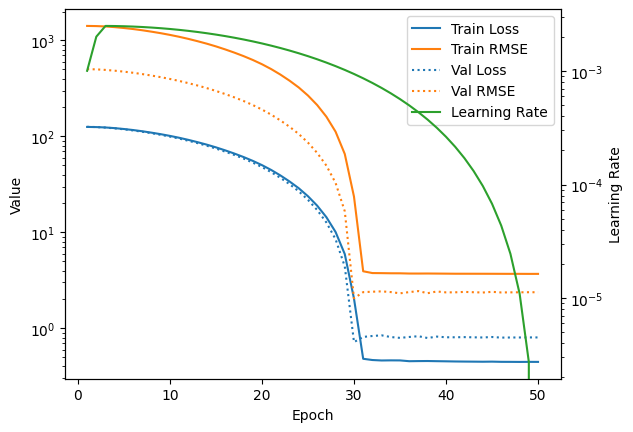

In [51]:
n = np.arange(1, EPOCHS+1)
metrics = {k: [float(i) for i in v] for k, v in train_metrics.items()}

fig, ax1 = plt.subplots()

ax1.plot(n, metrics["train_loss"], "C0", label="Train Loss")
ax1.plot(n, metrics["train_rmse"], "C1", label="Train RMSE")

ax1.plot(n, metrics["val_loss"], "C0:", label="Val Loss")
ax1.plot(n, metrics["val_rmse"], "C1:", label="Val RMSE")

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Value")
ax1.set_yscale("log")

ax2 = ax1.twinx()

ax2.plot(n, metrics["lr"], "C2-", label="Learning Rate")
ax2.set_ylabel("Learning Rate")
ax2.set_yscale("log")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.show()

# Comparison with Ground Truth

In [52]:
comparison_entity=["Afghanistan"]

In [53]:
model.eval()
data = []
for years in np.append(test_year, ood_test_year):
    print(years)
    regional_data, global_data = load_tensor(comparison_entity, np.arange(years, years + SEQ_LEN))
    pred = model(global_data, regional_data[:, :-1])

    pred = pred[:, -1, 1:].cpu().detach().numpy()
    data.append(scaler.inverse_transform(pred))

data = np.vstack(data)
test_y = np.arange(2008, 2021)
pd.DataFrame(data, columns=df_global.columns[1:])

2010
2011
2012


,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,81.011925,67.051659,31.848322,36.841770,6.513691,13.312814,33.971237,19384.638672,5.004270,85460.898438,8934.981445,100.892830,404271.93750,18.746086,14.652538
1,81.011932,67.051674,31.848326,36.841728,6.513687,13.312870,33.971222,19384.611328,5.004273,85460.804688,8934.983398,100.892723,404271.84375,18.746094,14.652553
2,81.011932,67.051689,31.848310,36.841709,6.513733,13.312927,33.971207,19384.617188,5.004271,85460.289062,8934.993164,100.892654,404272.87500,18.746098,14.652544


In [54]:
regional_data = []

for year in test_y:
    year = int(year)

    regional_data.append(torch.tensor(entity_groups[comparison_entity[0]][years_index[year]]))


regional_data = torch.stack(regional_data)
gt = regional_data.numpy()
gt = scaler.inverse_transform(gt[:, 1:])
pd.DataFrame(gt, columns=df_global.columns[1:])

,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,42.400000,16.7,21.17,0.19,0.0,0.54,73.972600,607.83350,1.94,3559.999943,364.663542,60.0,652230.0,33.93911,67.709953
1,46.740050,18.4,16.53,0.16,0.0,0.78,82.978720,975.04816,2.25,4880.000114,437.268740,60.0,652230.0,33.93911,67.709953
2,42.700000,20.0,15.15,0.19,0.0,0.75,79.787230,1182.89200,2.46,7110.000134,543.306526,60.0,652230.0,33.93911,67.709953
3,43.222020,21.8,12.61,0.18,0.0,0.60,76.923090,1436.11430,3.23,8930.000305,591.190030,60.0,652230.0,33.93911,67.709953
4,69.100000,23.0,15.36,0.14,0.0,0.74,84.090910,1324.12110,2.61,8079.999924,638.845852,60.0,652230.0,33.93911,67.709953
5,68.290650,24.8,16.86,0.22,0.0,0.89,80.180176,1060.79260,2.46,5989.999771,624.315454,60.0,652230.0,33.93911,67.709953
6,89.500000,26.1,18.93,0.16,0.0,1.00,86.206900,868.57620,2.25,4880.000114,614.223342,60.0,652230.0,33.93911,67.709953
7,71.500000,27.4,17.53,0.15,0.0,1.03,87.288140,970.08030,2.37,5949.999809,556.007221,60.0,652230.0,33.93911,67.709953
8,97.700000,28.6,19.92,0.15,0.0,1.06,87.603294,862.79114,2.24,5300.000191,512.012778,60.0,652230.0,33.93911,67.709953
9,97.700000,29.7,19.21,0.18,0.0,1.09,85.826775,829.31195,2.30,4780.000210,516.679862,60.0,652230.0,33.93911,67.709953


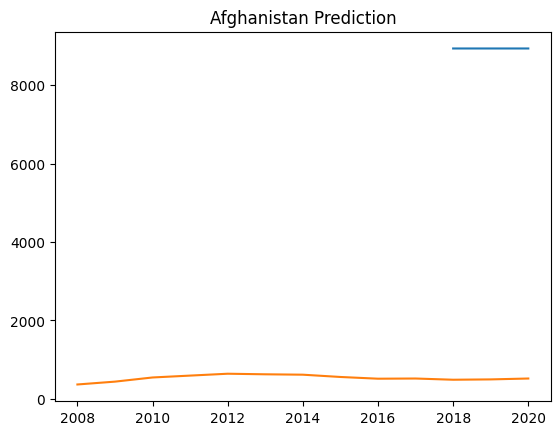

In [55]:
y = test_y[-3:]
plt.plot(y, data[:, -5], label="pred")
plt.plot(test_y, gt[:, -5], label="gt")
plt.title(comparison_entity[0] + " Prediction")
plt.show()